# Natural Language Processing (NLP) Template
Adapted for dataset https://scikit-learn.org/stable/datasets/real_world.html#newsgroups-dataset


### Step 1: Load Data

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (6, 4)

# All categories
#all_target_names = fetch_20newsgroups().target_names

# Load dataset here
category_list = [
    'alt.atheism',
    'talk.politics.guns',
    'comp.windows.x',
    'comp.graphics',
    'sci.space',
    'rec.autos',
    'rec.motorcycles', 
]

from sklearn.datasets import fetch_20newsgroups
X, y = fetch_20newsgroups(
    return_X_y=True,
    remove=('headers', 'footers', 'quotes'),
    categories=category_list,
)

# Replace numbers in y with category names

y = [category_list[i] for i in y]
y, X

(['talk.politics.guns',
  'rec.autos',
  'sci.space',
  'rec.motorcycles',
  'rec.autos',
  'sci.space',
  'rec.motorcycles',
  'rec.autos',
  'rec.motorcycles',
  'comp.windows.x',
  'alt.atheism',
  'rec.autos',
  'comp.windows.x',
  'rec.motorcycles',
  'comp.graphics',
  'rec.motorcycles',
  'comp.windows.x',
  'rec.autos',
  'comp.windows.x',
  'comp.graphics',
  'sci.space',
  'talk.politics.guns',
  'rec.motorcycles',
  'alt.atheism',
  'rec.autos',
  'alt.atheism',
  'talk.politics.guns',
  'rec.motorcycles',
  'rec.motorcycles',
  'alt.atheism',
  'rec.motorcycles',
  'rec.autos',
  'sci.space',
  'sci.space',
  'alt.atheism',
  'talk.politics.guns',
  'talk.politics.guns',
  'comp.windows.x',
  'alt.atheism',
  'sci.space',
  'comp.graphics',
  'alt.atheism',
  'comp.graphics',
  'comp.windows.x',
  'comp.graphics',
  'comp.windows.x',
  'talk.politics.guns',
  'sci.space',
  'comp.graphics',
  'alt.atheism',
  'sci.space',
  'talk.politics.guns',
  'alt.atheism',
  'alt.athe

### Step 2: Data Cleanup


In [2]:
import re

def basic_clean(text: str) -> str:
    # Lowercase
    text = text.lower()
    # Remove anything that's not a letter or space
    text = re.sub(r"[^a-z\s]", "", text)
    # Collapse multiple spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Cleanup the text data
X = [basic_clean(doc) for doc in X]
X

['okay ive received a whole lot of requests for the movie so for simplicitys sake i cant mail out any more than ive already received as of edt tuesday maybe itll pop up on a site sooner or later',
 'if that were true id go for it i have a few friends who we could pool our resources and do it maybe make it a prize kind of liek the solar car race in australia anybody game for a contest',
 'as a new bmw owner i was thinking about signing up for the moa but right now it is beginning to look suspiciously like throwing money down a rathole when you guys sort this out let me know',
 'if you havent heard yet us senator patty murrey a mom in tennis shoes is planning to introduce legislation to tax all handgun transactions and increase dealer licnese costs in order to raise money to cover the costs of uninsured shooting victums she plans to start with per year dealer fees and or so depending on the type of firearm per gun transaction she plans to make it federal she was elected in washington sta

Logistic Regression Training Accuracy: 0.9226
Logistic Regression Accuracy: 0.8960


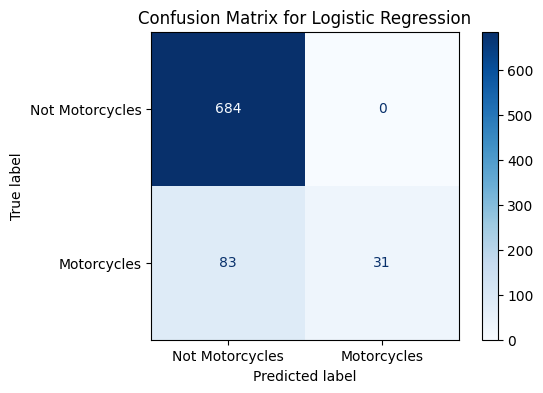

In [3]:
## Logistic Regression
# Predict if a document belongs to 'rec.motorcycles' or not

# Create binary labels for 'rec.motorcycles'
y_binary = [1 if label == 'rec.motorcycles' else 0 for label in y]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)

# Vectorize the text data using TF-IDF
vectorizer = TfidfVectorizer(max_features=1000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
# Train a logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

# Make predictions using the training set and print accuracy
y_train_pred = model.predict(X_train_vec)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Logistic Regression Training Accuracy: {train_accuracy:.4f}")

# Make predictions and evaluate the model
y_pred = model.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {accuracy:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Motorcycles', 'Motorcycles'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Logistic Regression")
plt.show()

### Step 3: Create Bag-of-Words or TF-IDF Matrix


### Step 4: Create a simple sentiment classifier

Now that we have numeric features from text, we can build a simple classifier to predict sentiment (positive/negative) based on course comments.


### Step 5: Clustering to explore topics

Use clustering algorithms (e.g., K-Means) to group similar comments together and explore common themes or topics in the feedback.

In [6]:
# NLP to group documents with similar content.
# Vectorize the text data using TF-IDF for clustering
vectorizer = TfidfVectorizer(max_features=1000)
X_vec = vectorizer.fit_transform(X)
# Apply KMeans clustering
num_clusters = 5
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(X_vec)

# Get cluster labels for each document
cluster_labels = kmeans.labels_

# Print the number of documents in each cluster
for i in range(num_clusters):
    print(f"Cluster {i}: {np.sum(cluster_labels == i)} documents")

# Compare the clusters with the original categories
cluster_category_counts = pd.crosstab(cluster_labels, y)
print("\nCluster vs Original Category Counts:")
print(cluster_category_counts)

Cluster 0: 1003 documents
Cluster 1: 720 documents
Cluster 2: 931 documents
Cluster 3: 838 documents
Cluster 4: 496 documents

Cluster vs Original Category Counts:
col_0  alt.atheism  comp.graphics  comp.windows.x  rec.autos  rec.motorcycles  \
row_0                                                                           
0              154            210              32        180              152   
1                3             41             320         55               10   
2              137            114              80        200              218   
3               87            141             110        110               90   
4               99             88              51         48               76   

col_0  sci.space  talk.politics.guns  
row_0                                 
0            206                  69  
1             31                 260  
2            108                  74  
3            167                 133  
4             86                  

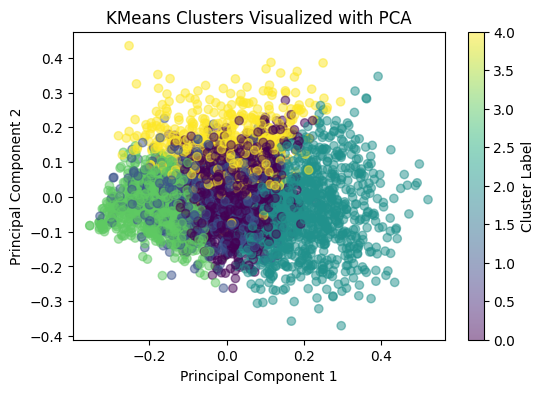

In [5]:


# Visualize the clusters using PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_vec.toarray())
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.5)
plt.title("KMeans Clusters Visualized with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label='Cluster Label')
plt.show()


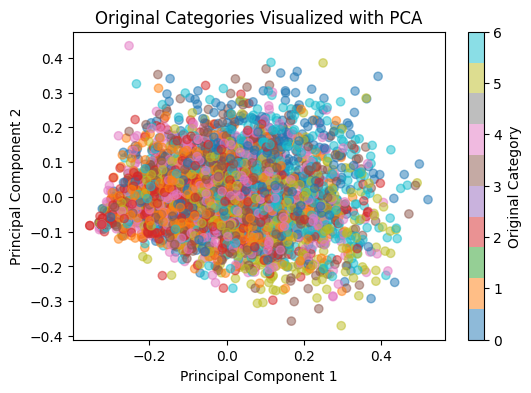

In [7]:
# Visualize original categories using PCA
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=[category_list.index(label) for label in y], cmap='tab10', alpha=0.5)
plt.title("Original Categories Visualized with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label='Original Category')
plt.show()